In [3]:
 # Install necessary libraries
!pip install torch datasets transformers scikit-learn gradio nltk seaborn matplotlib

In [4]:
import torch
from torch.utils.data import Dataset
from datasets import load_dataset
from transformers import (
    BertTokenizer, BertForNextSentencePrediction,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random
import nltk
from nltk.tokenize import sent_tokenize
import numpy as np

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [5]:
# Load dataset
raw_dataset = load_dataset("wikitext", "wikitext-103-raw-v1", split="train[:5%]")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/733k [00:00<?, ?B/s]

train-00000-of-00002.parquet:   0%|          | 0.00/157M [00:00<?, ?B/s]

train-00001-of-00002.parquet:   0%|          | 0.00/157M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [6]:
# Improved sentence pair creator
nltk.download('punkt_tab')
def create_sentence_pairs_better(dataset, max_pairs=3000):
    all_sentences = []
    for text in dataset['text']:
        lines = sent_tokenize(text)
        all_sentences.extend(lines)

    sentence_pairs = []
    for text in dataset['text']:
        lines = sent_tokenize(text)
        for i in range(len(lines) - 1):
            if len(lines[i].split()) > 5 and len(lines[i+1].split()) > 5:
                # Positive
                sentence_pairs.append((lines[i], lines[i+1], 0))
                # Negative
                while True:
                    sent2 = random.choice(all_sentences)
                    if sent2 not in lines:
                        break
                sentence_pairs.append((lines[i], sent2, 1))
            if len(sentence_pairs) >= max_pairs:
                return sentence_pairs
    return sentence_pairs

pairs = create_sentence_pairs_better(raw_dataset, max_pairs=3000)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [7]:
#Train/val/test split
train_pairs, temp_pairs = train_test_split(pairs, test_size=0.2, random_state=42)
val_pairs, test_pairs = train_test_split(temp_pairs, test_size=0.5, random_state=42)


In [8]:
# Dataset class
class NSPDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_len=128): # Changed _init_ to __init__
        self.examples = []
        for sent1, sent2, label in pairs:
            encoding = tokenizer(sent1, sent2, truncation=True, padding='max_length',
                                 max_length=max_len, return_tensors="pt")
            encoding = {k: v.squeeze() for k, v in encoding.items()}
            encoding['labels'] = torch.tensor(label)
            self.examples.append(encoding)

    def __len__(self): # Changed _len_ to __len__
        return len(self.examples)

    def __getitem__(self, idx): # Changed _getitem_ to __getitem__
        return self.examples[idx]

In [9]:

# Tokenizer and datasets
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
train_dataset = NSPDataset(train_pairs, tokenizer)
val_dataset = NSPDataset(val_pairs, tokenizer)
test_dataset = NSPDataset(test_pairs, tokenizer)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

In [10]:
# Model
model = BertForNextSentencePrediction.from_pretrained("bert-base-uncased")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [11]:
# Training args
training_args = TrainingArguments(
    output_dir="./results_bert",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [12]:
# Metrics function
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

In [13]:
# Trainer with early stopping
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


In [14]:
# Train
print("Training BERT...")
trainer.train()


Training BERT...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.031964,0.993333
2,0.087200,0.093079,0.986667
3,0.087200,0.086436,0.986667


TrainOutput(global_step=900, training_loss=0.05121590455373128, metrics={'train_runtime': 10750.5899, 'train_samples_per_second': 1.116, 'train_steps_per_second': 0.14, 'total_flos': 473599899648000.0, 'train_loss': 0.05121590455373128, 'epoch': 3.0})

Evaluating on test set...


Accuracy: 0.98
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       152
           1       0.99      0.97      0.98       148

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



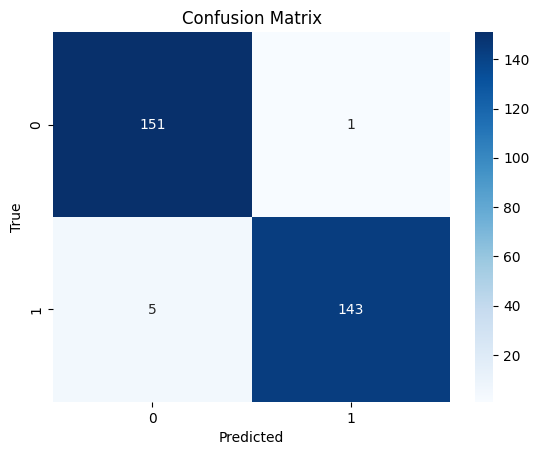

In [15]:
# Evaluate
print("Evaluating on test set...")
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate
preds = trainer_bert.predict(test_dataset)
y_true = preds.label_ids
y_pred = preds.predictions.argmax(axis=1)

# Print metrics
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred))

# Confusion matrix
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (BERT NSP)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
from transformers import BertTokenizer, BertForNextSentencePrediction, RobertaTokenizer, RobertaForSequenceClassification

# Initialize models and tokenizers (using pre-trained models)
bert_model = BertForNextSentencePrediction.from_pretrained("bert-base-uncased")
roberta_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [3]:
# Prediction function for BERT and RoBERTa with visualizations
def predict_nsp_ensemble(sent1, sent2):
    # BERT prediction
    inputs_bert = bert_tokenizer(sent1, sent2, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs_bert = bert_model(**inputs_bert)
        probs_bert = torch.softmax(outputs_bert.logits, dim=1)
        pred_bert = torch.argmax(probs_bert, dim=1).item()

    # RoBERTa prediction
    inputs_roberta = roberta_tokenizer(sent1, sent2, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs_roberta = roberta_model(**inputs_roberta)
        probs_roberta = torch.softmax(outputs_roberta.logits, dim=1)
        pred_roberta = torch.argmax(probs_roberta, dim=1).item()

    # Combine predictions (Majority vote: if BERT and RoBERTa agree, output that; otherwise, default to 1)
    final_pred = 0 if (pred_bert + pred_roberta) <= 1 else 1  # Majority vote (0 = Next, 1 = Not Next)


In [12]:
# Prediction function for BERT and RoBERTa with visualizations
def predict_nsp_ensemble(sent1, sent2):
    # BERT prediction
    inputs_bert = bert_tokenizer(sent1, sent2, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs_bert = bert_model(**inputs_bert)
        probs_bert = torch.softmax(outputs_bert.logits, dim=1)
        pred_bert = torch.argmax(probs_bert, dim=1).item()

    # RoBERTa prediction
    inputs_roberta = roberta_tokenizer(sent1, sent2, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs_roberta = roberta_model(**inputs_roberta)
        probs_roberta = torch.softmax(outputs_roberta.logits, dim=1)
        pred_roberta = torch.argmax(probs_roberta, dim=1).item()

    # Combine predictions (majority vote)
    final_pred = 0 if (pred_bert + pred_roberta) <= 1 else 1  # Majority vote (0 = Next, 1 = Not Next)

    # Visualize probabilities
    plt.figure(figsize=(8, 5))
    labels = ['Next', 'Not Next']
    bert_probs = probs_bert[0].cpu().numpy()
    roberta_probs = probs_roberta[0].cpu().numpy()

    # Bar chart for individual model probabilities
    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots()
    ax.bar(x - width/2, bert_probs, width, label='BERT', color='blue')
    ax.bar(x + width/2, roberta_probs, width, label='RoBERTa', color='orange')

    ax.set_ylabel('Probability')
    ax.set_title('BERT vs RoBERTa Prediction Probabilities')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return f"Final Prediction: {'NEXT' if final_pred == 0 else 'NOT NEXT'} (BERT: {pred_bert}, RoBERTa: {pred_roberta})"





In [13]:

# Gradio Interface
def launch_gradio():
    gr.Interface(
        fn=predict_nsp_ensemble,
        inputs=[gr.Textbox(label="Sentence 1"), gr.Textbox(label="Sentence 2")],
        outputs="text",
        title="Next Sentence Prediction (BERT & RoBERTa Ensemble)",
        description="Predict whether two sentences follow each other logically using BERT and RoBERTa models combined. Visualization of predictions provided.",
        examples=[
            ["The sky is blue.", "The grass is green."],
            ["She went to the market.", "The sun was setting."]
        ]
    ).launch()

# Launch the Gradio interface
launch_gradio()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://67b670bb2733b1c6ac.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
